In [ ]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from IPython.display import display
import sklearn
from sklearn import set_config
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.naive_bayes import CategoricalNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, cross_validate
from sklearn.metrics import PrecisionRecallDisplay, ConfusionMatrixDisplay
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline as ImbPipeline
import shap

from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler,
    KBinsDiscretizer,
    FunctionTransformer,
    LabelEncoder
)
from sklearn.metrics import (
    f1_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    classification_report
)

set_config(transform_output="pandas") # For easier debugging with DataFrames and because we work with catecory data type

In [2]:
df = pd.read_parquet('montgomery_crash_reporting_processed.parquet')

# feature selctor

In [3]:
feature_summary = pd.DataFrame({
    'Feature': df.columns,
    'Unique_Values': [df[col].nunique() for col in df.columns],
    'Data_Type': [df[col].dtype for col in df.columns]
})
feature_summary

,Feature,Unique_Values,Data_Type
0,agency_name,6,category
1,acrs_report_type,3,category
2,hit_run,2,Int64
3,route_type,5,category
4,distance,5834,float64
5,at_fault,3,category
6,collision_type,6,category
7,weather,7,category
8,surface_condition,4,category
9,light,6,category


In [ ]:
def create_cyclic_features(df):
    """
    Transforms temporal features into sine/cosine components.
    Fixes the TypeError by explicitly casting mapped values to float.
    """
    df = df.copy()
    
    # --- 1. Basic numeric cycles (Hour, Month, Day of week) ---
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'].astype(float) / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'].astype(float) / 24)
    
    df['month_sin'] = np.sin(2 * np.pi * (df['month'].astype(float) - 1) / 12)
    df['month_cos'] = np.cos(2 * np.pi * (df['month'].astype(float) - 1) / 12)
    
    df['dow_sin'] = np.sin(2 * np.pi * df['day_of_week'].astype(float) / 7)
    df['dow_cos'] = np.cos(2 * np.pi * df['day_of_week'].astype(float) / 7)
    
    # --- 2. Season cycle ---
    # Ensure all possible values in your data are covered by the map
    season_map = {'Winter': 0, 'Spring': 1, 'Summer': 2, 'Autumn': 3}
    if 'season' in df.columns:
        # Crucial fix: .astype(float) after mapping
        season_num = df['season'].map(season_map).astype(float)
        df['season_sin'] = np.sin(2 * np.pi * season_num / 4)
        df['season_cos'] = np.cos(2 * np.pi * season_num / 4)
    
    # --- 3. Time of day cycle ---
    # Double-check if 'Mid_day' should be 'Afternoon' based on your unique values
    time_map = {'Morning': 0, 'Mid_day': 1, 'Evening': 2, 'Night': 3}
    if 'time_of_day' in df.columns:
        # Crucial fix: .astype(float) after mapping
        time_num = df['time_of_day'].map(time_map).astype(float)
        df['time_sin'] = np.sin(2 * np.pi * time_num / 4)
        df['time_cos'] = np.cos(2 * np.pi * time_num / 4)
    
    
    return df

In [ ]:
# ================
# FEATURE GROUPS 
# =================

TARGET_COL = 'acrs_report_type'

# --- Numeric Features ---
# includes the generated cyclic sine/cosine features
NUMERIC_FEATS = [
    'distance', 
    'crash_year',
    'hour_sin', 'hour_cos',
    'month_sin', 'month_cos',
    'dow_sin', 'dow_cos',
    'season_sin', 'season_cos',
    'time_sin', 'time_cos'
]

# --- Cyclic Features (Before transformation) ---
# These will be passed through the create_cyclic_features function
CYCLIC_FEATS = ['hour', 'month', 'day_of_week', 'season', 'time_of_day']

# --- Binary Features (0/1) ---
BINARY_FEATS = [
    'is_weekend',
    'is_holiday',
    'is_two_way', # Derivative of road_division_cat
    'driver_substance_abuse',
    # Road Grade Binary Indicators (Handled manually in preprocessing)
    'road_grade_Downhill', 'road_grade_Hillcrest', 'road_grade_Level', 
    'road_grade_On_Bridge', 'road_grade_Other', 'road_grade_Sag', 
    'road_grade_Uphill', 'road_grade_Not_Relevant',
    # Road Alignment Binary Indicators
    'road_alignment_Curve_Left', 'road_alignment_Curve_Right', 
    'road_alignment_Other', 'road_alignment_Straight', 
    'road_alignment_Not_Relevant'
]

# --- Nominal Categorical Features ---
# ther is redundancy with 'road_grade_cat', 'road_alignment_cat' and 'road_division_cat', it will be handled in preprocessing
CAT_FEATS = [
    'route_type', 
    'weather', 
    'junction', 
    'road_condition',
    'light', 
    'surface_condition', 
    'road_grade_cat',    
    'road_alignment_cat',
    'road_division_cat', 
    'division_type', # Derivative of road_division_cat
    'division',  # Derivative of road_division_cat
    'left_turn', # Derivative of road_division_cat
    'traffic_control'
]


how its lock at hi level

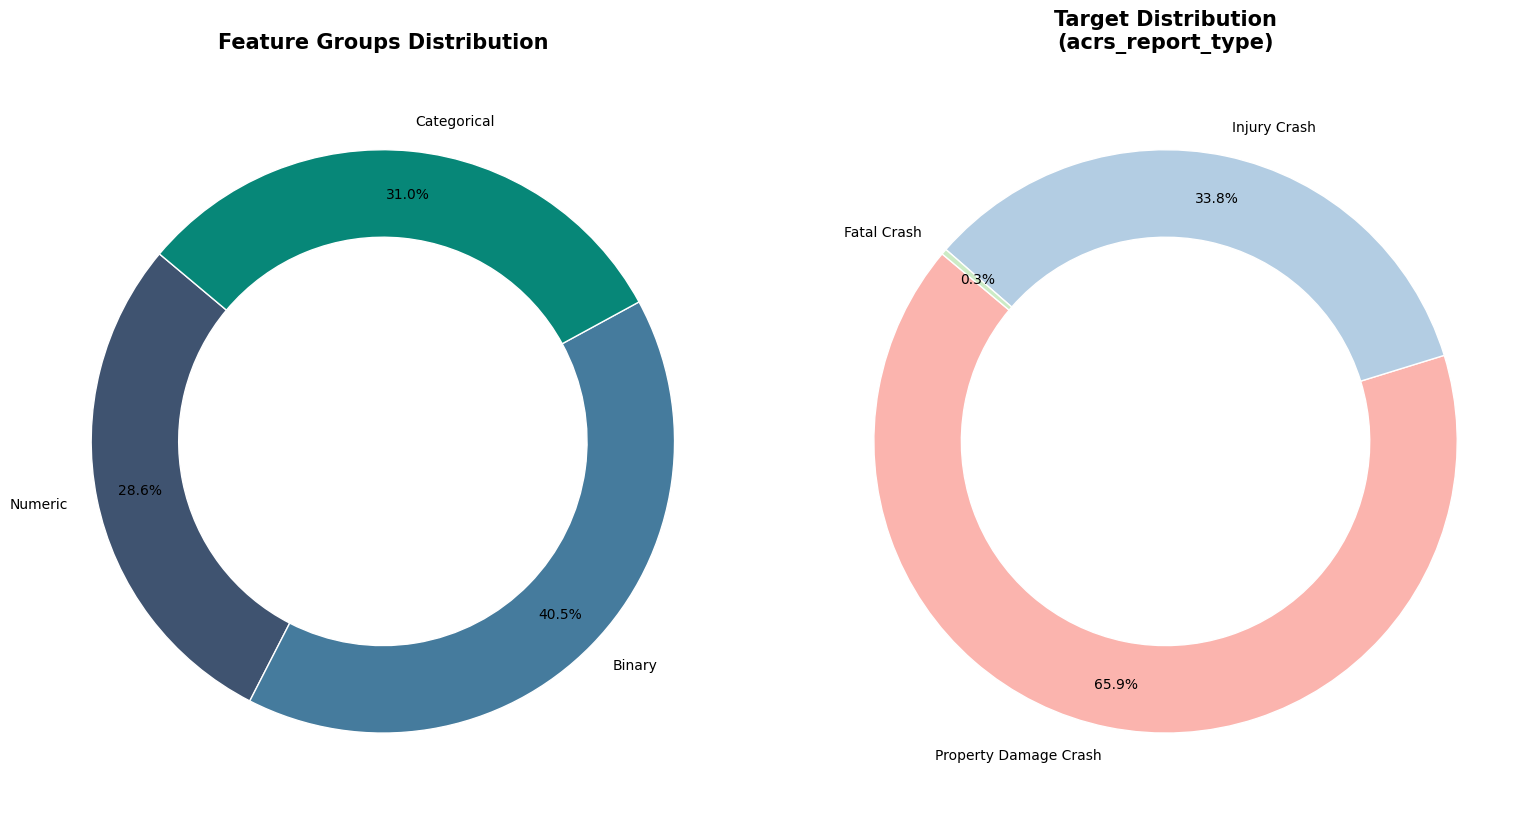

In [ ]:
feature_groups = {
    'Numeric': len(NUMERIC_FEATS),
    'Binary': len(BINARY_FEATS),
    'Categorical': len(CAT_FEATS)
}

target_counts = df[TARGET_COL].value_counts()


fig, ax = plt.subplots(1, 2, figsize=(16, 8))

colors_feat = ["#3f5370", "#457b9d", "#078778"]
ax[0].pie(feature_groups.values(), labels=feature_groups.keys(), autopct='%1.1f%%', 
          startangle=140, pctdistance=0.85, colors=colors_feat, 
          wedgeprops={'width': 0.3, 'edgecolor': 'w'})

ax[0].set_title('Feature Groups Distribution', fontsize=15, pad=20, fontweight='bold')


colors_target = plt.cm.Pastel1.colors
ax[1].pie(target_counts, labels=target_counts.index, autopct='%1.1f%%', 
          startangle=140, pctdistance=0.85, colors=colors_target, 
          wedgeprops={'width': 0.3, 'edgecolor': 'w'})

ax[1].set_title(f'Target Distribution\n({TARGET_COL})', fontsize=15, pad=20, fontweight='bold')

plt.tight_layout()
plt.show()

# Tree Models (CB, LGBM, RF)

In [66]:
# ============================================================
# FEATURE SELECTION 
# Strategy: Use parent categorical columns instead of binary 
# derivatives because tree models can split optimally on categories rather
# than fragmented binary indicators.
# ============================================================

# -- Categorical --
tree_cat_selection = [
    'route_type', 'weather', 'junction', 'road_condition', 'light',
    'surface_condition', 
    'road_grade_cat', 
    'road_alignment_cat', 
    'road_division_cat', 
    'traffic_control'
]

# -- Binary --
tree_bin_selection = [c for c in BINARY_FEATS if not (
    c.startswith('road_grade_') or 
    c.startswith('road_alignment_') or 
    c == 'is_two_way')] # Derivative of road_division_cat

native_preprocessor = ColumnTransformer(
    transformers=[
        # Numeric/Binary: keep NaNs; CatBoost handles missing values natively
        # Categorical: encode missingness explicitly as "MISSING"
        ('num', 'passthrough', NUMERIC_FEATS),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='MISSING')),
            ('cast', FunctionTransformer(lambda x: x.astype('category'), validate=False))
        ]), tree_cat_selection), 
        ('bin', 'passthrough', tree_bin_selection)
    ],
    remainder='drop',
    verbose_feature_names_out=False
)



## CatBoost

In [ ]:
cb_pipeline = Pipeline([
     ('preprocessor', native_preprocessor),
    ('model', CatBoostClassifier(
        cat_features = tree_cat_selection,
        auto_class_weights='Balanced', # Increases penalty for mistakes on rare classes
        verbose=50,
        allow_writing_files=False,
    #    loss_function='MultiClass', # penalizes the model for being "confident and wrong" + softmax
        loss_function='Logloss',
        random_state=42
    ))
])


## LightGBM

In [ ]:
lgbm_pipeline = Pipeline([
    ('preprocessor', native_preprocessor),
    ('model', LGBMClassifier(
        class_weight='balanced', # Increases penalty for mistakes on rare classes
        verbose=10,
        n_jobs=-1,
        categorical_feature='auto',
       # objective='multiclass', # multi-class classification, softmax
        objective = 'binary',
       # num_class=3, 
       # metric='multi_logloss', # penalizes the model for being "confident and wrong"
        metric='binary_logloss',
        importance_type='gain', # Better for interpretation and more fit to our goal
        random_state=42
    ))
])

## Random Forest

In [ ]:
rf_preprocessor = ColumnTransformer(
    transformers=[
        # Numeric: Simple median imputation
        ('num', SimpleImputer(strategy='median'), NUMERIC_FEATS), 
        
        # Binary: Imputing missing values (RF fails on NaNs in sklearn)
        ('bin', SimpleImputer(strategy='most_frequent'), tree_bin_selection),

        # Categorical: All tree categories via OHE
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
            ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False)) 
        ]), tree_cat_selection)
    ],
    remainder='drop',
    verbose_feature_names_out=False
)

rf_pipeline = Pipeline([
    ('preprocessor', rf_preprocessor),
    ('model', RandomForestClassifier(
        class_weight='balanced',  # importent for rare classes

        n_estimators=200,      
        max_depth=15,          # Limit depth to prevent Overfitting on noisy data
        min_samples_split=10,  # Require at least 10 samples to split a node
        min_samples_leaf=4,    # helps smooth the model against noise
        n_jobs=-1,         
        random_state=42,
        verbose=0           
    ))
])

# Logistic Regression

In [ ]:
# Categorical: here we prefer to work with the features which derivative
# of the catgory features, as they may provide clearer signals for LR.
lr_cat_selection = [c for c in CAT_FEATS if c not in [
    'road_grade_cat', 
    'road_alignment_cat', 
    'road_division_cat', 
    'surface_condition'
]]


lr_preprocessor = ColumnTransformer(
    transformers=[
        # Numeric: scale + impute
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()) 
        ]), NUMERIC_FEATS),

        ('bin', SimpleImputer(strategy='most_frequent'), BINARY_FEATS),

        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
            ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), lr_cat_selection)
    ],
    remainder='drop',
    verbose_feature_names_out=False
)


lr_pipeline = Pipeline([
    ('preprocessor', lr_preprocessor),
    ('model', LogisticRegression(
        # --- Solver & Convergence ---
        solver='lbfgs',          # The standard engine (Stable, handles Multiclass, supports L2, suitable for our data size)
        max_iter=500,            # Changed from default (100) to ensure convergence on imbalanced data
        
        # --- Class Imbalance ---
        class_weight='balanced', # Forces the model to give more weight to rare classes, maybe we will manually weight later
        
        # --- Technical ---
        n_jobs=-1,             
        random_state=42          
        
        # --- Hidden Defaults ---
        # penalty='l2' (Standard Ridge Regularization is on)
        # C=1.0 (Moderate regularization strength)
        # multi_class='auto' (Automatically selects Softmax/Multinomial)
    ))
])

# Categorial Naive Bayes

In [ ]:
# NB is extremely sensitive to correlated features (double-counting). 
# also he asumes indrependent features so we prfer the "father" features and not their derivatives.
# We use the clean "Tree" selection.

nb_cat_selection = tree_cat_selection + ['crash_year']  # Moving discrete numeric to categorical for better NB performance
nb_num_feats = [c for c in NUMERIC_FEATS if c != 'crash_year']


nb_preprocessor = ColumnTransformer(
    transformers=[
        # --- Discretizing Numeric Features ---
        # CategoricalNB requires discrete categories. 
        # Quantile strategy ensures bins have equal number of samples.
        ('num_binned', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('discretizer', KBinsDiscretizer(
                n_bins=15, 
                encode='ordinal', 
                strategy='quantile'
            ))
        ]), nb_num_feats),
        
        # --- Binary Features ---
        # Already discrete (0/1), just need to ensure no NaNs.
        ('bin', SimpleImputer(strategy='most_frequent'), tree_bin_selection),
        
        # --- Categorical Features ---
        # Shifted to ensure all values are non-negative integers.
        ('cat_all', Pipeline([
            ('to_str', FunctionTransformer(lambda x: x.astype(str), validate=False)),
            ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
            ('ordinal', OrdinalEncoder(
                handle_unknown='use_encoded_value',
                unknown_value=-1 
            )),
            ('shift', FunctionTransformer(func=lambda x: x + 1, validate=False
            ))
        ]), nb_cat_selection)
    ],
    remainder='drop',
    verbose_feature_names_out=False
)

nb_pipeline = ImbPipeline([
    ('preprocessor', nb_preprocessor),
    
    # NB does not have a 'class_weight' parameter in sklearn.
    # Resampling is necessary to handle the minority classes.
    ('resampler', RandomOverSampler(
       # sampling_strategy='not majority', 
        sampling_strategy = 0.8,
        random_state=42
    )),
    
    ('model', CategoricalNB(
        alpha=0.5  # Laplace smoothing to avoid zero probabilities. high -> more wheigt to prior. low -> more weight to data.
    ))
])

# comparing the models

In [64]:
y = df[TARGET_COL]
X_raw = df.drop(columns=[TARGET_COL])

X = create_cyclic_features(X_raw) # creates the hour_sin, month_cos etc. features we defined

# --- Stratified Split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- Target Encoding ---
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

target_names = list(le.classes_)

counts = Counter(y_train_encoded)
total = len(y_train_encoded)

# Building the summary table
summary_data = []
for i, class_name in enumerate(le.classes_):
    count = counts[i]
    summary_data.append({
        'Label': i,
        'Class Name': class_name,
        'Count': f"{count:,}",
        'Percentage': f"{(count/total)*100:.2f}%"
    })

# Identifying the minority class (index and name) for the benchmark
minority_class_val = min(counts, key=counts.get)
minority_class_name = le.classes_[minority_class_val]

print("Target Variable Summary (Train Set):")
print("-" * 45)
print(pd.DataFrame(summary_data).to_string(index=False))
print("-" * 45)
print(f"Target Minority Class: {minority_class_val} ({minority_class_name})\n")

Target Variable Summary (Train Set):
---------------------------------------------
 Label            Class Name  Count Percentage
     0           Fatal Crash    295      0.32%
     1          Injury Crash 31,601     33.81%
     2 Property Damage Crash 61,577     65.88%
---------------------------------------------
Target Minority Class: 0 (Fatal Crash)



In [ ]:
def run_benchmark(pipelines_dict, X_train, y_train, X_test, y_test, minority_class_idx, target_names):
    """
    Evaluates multiple pipelines and returns a performance leaderboard.
    """
    results = []
    
    for name, pipe in pipelines_dict.items():
        print(f"Processing: {name}...")
        
        # Training
        start_time = time.time()
        pipe.fit(X_train, y_train)
        train_time = time.time() - start_time
        
        # Prediction
        y_pred = pipe.predict(X_test)
        
        # Global Metrics
        f1_macro = f1_score(y_test, y_pred, average='macro')
        bal_acc = balanced_accuracy_score(y_test, y_pred)
        
        # Per-class Metrics
        # Using labels=range(len(target_names)) to match our 0, 1, 2 encoding
        prec, rec, f1_per_class, _ = precision_recall_fscore_support(
            y_test, y_pred, labels=range(len(target_names)), zero_division=0
        )
        
        # Store results for the specific minority class index
        results.append({
            'Model': name,
            'F1 Macro': round(f1_macro, 4),
            'Balanced Acc': round(bal_acc, 4),
            'Min. Recall': round(rec[minority_class_idx], 4),
            'Min. Precision': round(prec[minority_class_idx], 4),
            'Min. F1': round(f1_per_class[minority_class_idx], 4),
            'Time (s)': round(train_time, 2)
        })
        
        # Intermediate output for tracking with CATEGORY NAMES
        print(f"\n Classification Report for {name}:")
        print(classification_report(y_test, y_pred, target_names=target_names, zero_division=0, digits=3))
        print("-" * 60)

    # Leaderboard creation
    leaderboard = pd.DataFrame(results).sort_values('F1 Macro', ascending=False)
    return leaderboard

# ======================================================
# 4. EXECUTION
# ======================================================
pipelines = {
    'LR': lr_pipeline,
    'NB': nb_pipeline,
    'RF': rf_pipeline,
    'CB': cb_pipeline,  
    'LGBM': lgbm_pipeline 
}

# IMPORTANT: Using the encoded variables and names from your first block
leaderboard = run_benchmark(
    pipelines, 
    X_train, 
    y_train_encoded, 
    X_test, 
    y_test_encoded, 
    minority_class_val, # The index (0, 1, or 2)
    target_names        # The list of strings ('Minor', etc.)
)

leaderboard

🚀 Processing: LR...

📊 Classification Report for LR:
                       precision    recall  f1-score   support

          Fatal Crash      0.009     0.703     0.017        74
         Injury Crash      0.417     0.475     0.444      7900
Property Damage Crash      0.766     0.418     0.541     15395

             accuracy                          0.438     23369
            macro avg      0.397     0.532     0.334     23369
         weighted avg      0.645     0.438     0.507     23369

------------------------------------------------------------
🚀 Processing: NB...


C:\Users\אליאור\AppData\Roaming\Python\Python311\site-packages\sklearn\preprocessing\_discretization.py:307: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
C:\Users\אליאור\AppData\Roaming\Python\Python311\site-packages\sklearn\preprocessing\_discretization.py:307: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 1 are removed. Consider decreasing the number of bins.
  warnings.warn(
C:\Users\אליאור\AppData\Roaming\Python\Python311\site-packages\sklearn\preprocessing\_discretization.py:307: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 2 are removed. Consider decreasing the number of bins.
  warnings.warn(
C:\Users\אליאור\AppData\Roaming\Python\Python311\site-packages\sklearn\preprocessing\_discretization.py:307: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 3 are removed. Consider decreasing the number of bins.
  warning


📊 Classification Report for NB:
                       precision    recall  f1-score   support

          Fatal Crash      0.007     0.635     0.015        74
         Injury Crash      0.393     0.621     0.481      7900
Property Damage Crash      0.815     0.245     0.377     15395

             accuracy                          0.373     23369
            macro avg      0.405     0.500     0.291     23369
         weighted avg      0.670     0.373     0.411     23369

------------------------------------------------------------
🚀 Processing: RF...

📊 Classification Report for RF:
                       precision    recall  f1-score   support

          Fatal Crash      0.014     0.027     0.018        74
         Injury Crash      0.420     0.639     0.507      7900
Property Damage Crash      0.747     0.543     0.629     15395

             accuracy                          0.574     23369
            macro avg      0.394     0.403     0.385     23369
         weighted avg      0.

C:\Users\אליאור\AppData\Roaming\Python\Python311\site-packages\lightgbm\basic.py:2137: UserWarning: categorical_feature keyword has been found in `params` and will be ignored.
Please use categorical_feature argument of the Dataset constructor to pass this parameter.
  _log_warning(
C:\Users\אליאור\AppData\Roaming\Python\Python311\site-packages\lightgbm\basic.py:2159: UserWarning: categorical_feature in param dict is overridden.
  _log_warning(f"{cat_alias} in param dict is overridden.")


[LightGBM] [Warning] categorical_feature is set=auto, categorical_column=12,13,14,15,16,17,18,19,20,21 will be ignored. Current value: categorical_feature=auto
[LightGBM] [Debug] Dataset::GetMultiBinFromSparseFeatures: sparse rate 0.781239
[LightGBM] [Debug] Dataset::GetMultiBinFromAllFeatures: sparse rate 0.290759
[LightGBM] [Debug] init for col-wise cost 0.045155 seconds, init for row-wise cost 0.068312 seconds
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.053587 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Debug] Using Sparse Multi-Val Bin
[LightGBM] [Info] Total Bins 436
[LightGBM] [Info] Number of data points in the train set: 93473, number of used features: 25
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Debug] Trai

we need to write here conclusin from the outputs  
talk way catboost is not so shine (the graph in the next block)

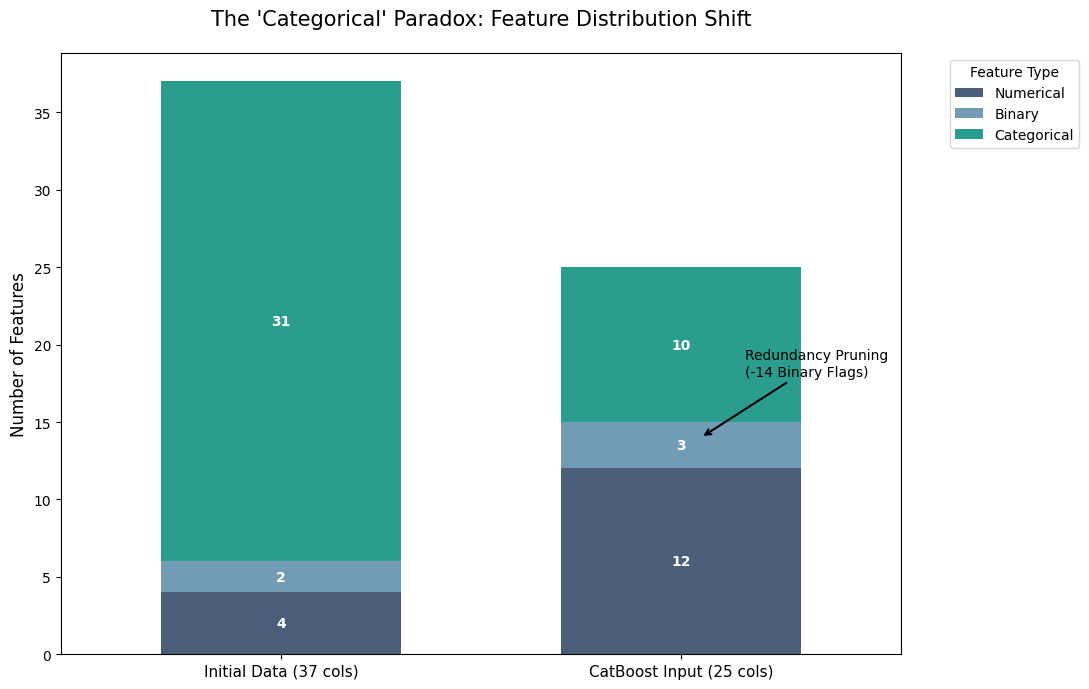

In [ ]:
data = {
    'Numerical': [4, 12],
    'Binary': [2, 3],
    'Categorical': [31, 10]
}

index = ['Initial Data (37 cols)', 'CatBoost Input (25 cols)']
df_plot = pd.DataFrame(data, index=index)

# 2. פלטת הצבעים שביקשת (נומרי, בינארי קרובים | קטגורי שונה)
colors_feat = ["#1d3557cb", "#457b9dc1", "#2a9d8f"]

# 3. יצירת הגרף
ax = df_plot.plot(kind='bar', stacked=True, color=colors_feat, figsize=(11, 7), width=0.6)

# הוספת תוויות מספרים בתוך הברים
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    if height > 0:
        x, y = p.get_xy() 
        ax.text(x+width/2, y+height/2, f'{int(height)}', ha='center', va='center', color='white', fontweight='bold')

# עיצוב מסביב
plt.title("The 'Categorical' Paradox: Feature Distribution Shift", fontsize=15, pad=20)
plt.ylabel("Number of Features", fontsize=12)
plt.xticks(rotation=0, fontsize=11)
plt.legend(title="Feature Type", bbox_to_anchor=(1.05, 1), loc='upper left')

# הוספת הערה על ה-Redundancy שצמצמת
plt.annotate('Redundancy Pruning\n(-14 Binary Flags)', 
             xy=(1.05, 14), xytext=(1.16, 18),
             arrowprops=dict(arrowstyle='->', lw=1.5, color='black'))

plt.tight_layout()
plt.show()

הסבר כאן שבחרנו קאטבוסט במחשבה שהוא יהיה הכי טוב כי התחלנו את הניתוח עם הרבה פיצ'רים קטגוריאלים אבל בפועל אחרי פרה פרוססינג זה בערך הגיע לחצי. מה שגרם לו לבצע "רק" כמו האחרים

# בחינה של איחוד עמודת המטרה

להכניס כאן הסבר למה אנחנו רוצים לבדוק את זה  
בעיר על הרקע שאנחנו לא מחפשים לרדוך אחרי הקטגוריה הנדירה (שבמקרה שלנו מאוד נדירה) המטרה שלנו היא לגזור תובנות ברות עשייה ולהשיג מודל מאוזן

In [32]:
df[TARGET_COL].value_counts(normalize=True)

acrs_report_type
Property Damage Crash    0.658770
Injury Crash             0.338072
Fatal Crash              0.003158
Name: proportion, dtype: float64

In [ ]:
# איחוד המחלקות: Fatal ו-Injury הופכות ל-"Casualty"
# Property Damage נשארת כפי שהיא
y = df[TARGET_COL].map({
    'Fatal Crash': 'Casualty',
    'Injury Crash': 'Casualty',
    'Property Damage Crash': 'Property Damage'
})


# פיצול מחדש (Stratified נשמר)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# קידוד מחדש (Casualty יהיה 0, Property Damage יהיה 1)
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

target_names = list(le.classes_)
minority_class_val = min(Counter(y_train_encoded), key=Counter(y_train_encoded).get)

print(f"New Target Classes: {target_names}")
print(f"Minority Class (Casualty) size: {np.mean(y_train_encoded == 0):.2%}")

New Target Classes: ['Casualty', 'Property Damage']
Minority Class (Casualty) size: 34.12%


In [ ]:
leaderboard_2 = run_benchmark(
    pipelines, 
    X_train, 
    y_train_encoded, 
    X_test, 
    y_test_encoded, 
    minority_class_val, # The index (0, 1, or 2)
    target_names        # The list of strings ('Minor', etc.)
)

leaderboard_2

🚀 Processing: LR...

📊 Classification Report for LR:
                 precision    recall  f1-score   support

       Casualty      0.417     0.657     0.510      7974
Property Damage      0.747     0.525     0.617     15395

       accuracy                          0.570     23369
      macro avg      0.582     0.591     0.564     23369
   weighted avg      0.635     0.570     0.581     23369

------------------------------------------------------------
🚀 Processing: NB...


C:\Users\אליאור\AppData\Roaming\Python\Python311\site-packages\sklearn\preprocessing\_discretization.py:307: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
C:\Users\אליאור\AppData\Roaming\Python\Python311\site-packages\sklearn\preprocessing\_discretization.py:307: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 1 are removed. Consider decreasing the number of bins.
  warnings.warn(
C:\Users\אליאור\AppData\Roaming\Python\Python311\site-packages\sklearn\preprocessing\_discretization.py:307: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 2 are removed. Consider decreasing the number of bins.
  warnings.warn(
C:\Users\אליאור\AppData\Roaming\Python\Python311\site-packages\sklearn\preprocessing\_discretization.py:307: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 3 are removed. Consider decreasing the number of bins.
  warning


📊 Classification Report for NB:
                 precision    recall  f1-score   support

       Casualty      0.392     0.819     0.531      7974
Property Damage      0.786     0.343     0.478     15395

       accuracy                          0.506     23369
      macro avg      0.589     0.581     0.504     23369
   weighted avg      0.651     0.506     0.496     23369

------------------------------------------------------------
🚀 Processing: RF...

📊 Classification Report for RF:
                 precision    recall  f1-score   support

       Casualty      0.424     0.639     0.509      7974
Property Damage      0.746     0.550     0.633     15395

       accuracy                          0.580     23369
      macro avg      0.585     0.594     0.571     23369
   weighted avg      0.636     0.580     0.591     23369

------------------------------------------------------------
🚀 Processing: CB...
Learning rate set to 0.099731
0:	learn: 0.6888635	total: 481ms	remaining: 8m
50:	l

C:\Users\אליאור\AppData\Roaming\Python\Python311\site-packages\lightgbm\basic.py:2137: UserWarning: categorical_feature keyword has been found in `params` and will be ignored.
Please use categorical_feature argument of the Dataset constructor to pass this parameter.
  _log_warning(
C:\Users\אליאור\AppData\Roaming\Python\Python311\site-packages\lightgbm\basic.py:2159: UserWarning: categorical_feature in param dict is overridden.
  _log_warning(f"{cat_alias} in param dict is overridden.")


[LightGBM] [Warning] categorical_feature is set=auto, categorical_column=12,13,14,15,16,17,18,19,20,21 will be ignored. Current value: categorical_feature=auto
[LightGBM] [Debug] Dataset::GetMultiBinFromSparseFeatures: sparse rate 0.781185
[LightGBM] [Debug] Dataset::GetMultiBinFromAllFeatures: sparse rate 0.290741
[LightGBM] [Debug] init for col-wise cost 0.010294 seconds, init for row-wise cost 0.039939 seconds
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.019524 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Debug] Using Sparse Multi-Val Bin
[LightGBM] [Info] Total Bins 437
[LightGBM] [Info] Number of data points in the train set: 93473, number of used features: 25
[LightGBM] [Info] Start training from score -0.693147
[LightGBM] [Info] Start training from score -0.693147
[LightGBM] [Info] Start training from score -34.538776
[LightGBM] [Debug] Tra

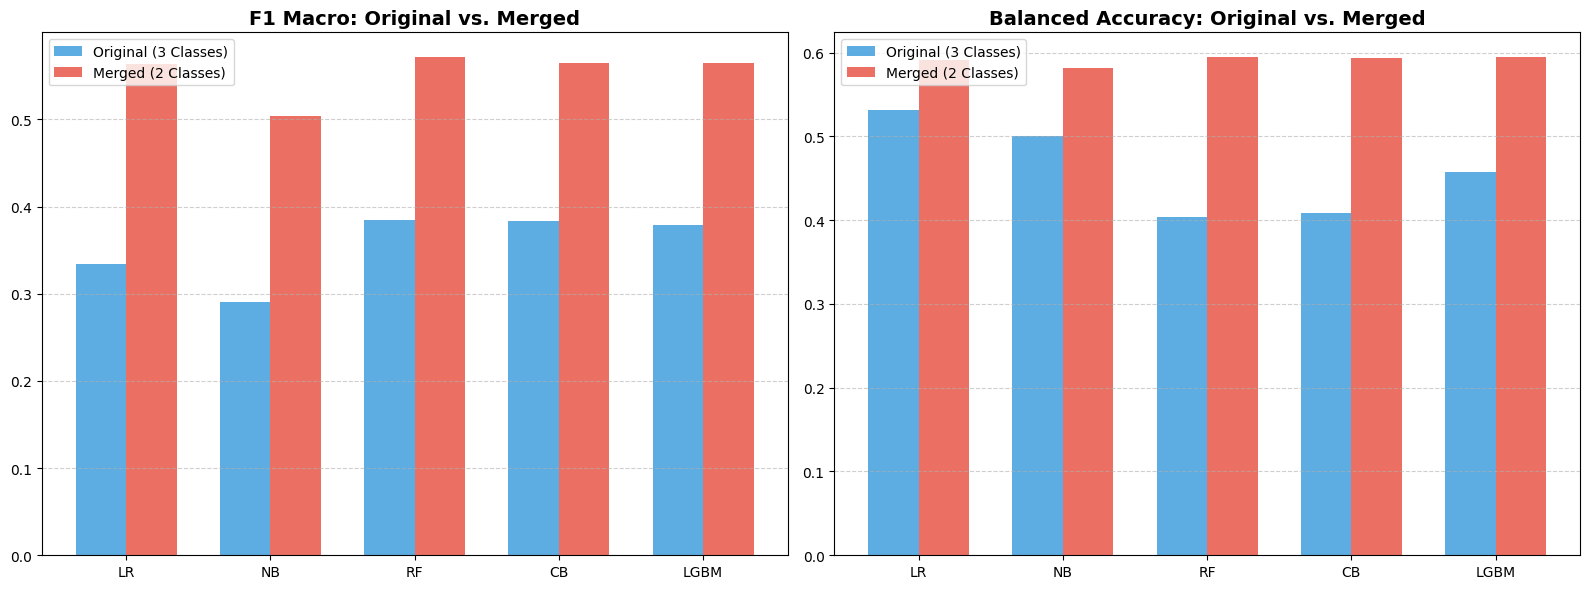

In [ ]:
models_order = ['LR', 'NB', 'RF', 'CB', 'LGBM']
df1 = leaderboard.set_index('Model').reindex(models_order)
df2 = leaderboard_2.set_index('Model').reindex(models_order)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
x = np.arange(len(models_order))
width = 0.35

# גרף 1: F1 Macro
ax[0].bar(x - width/2, df1['F1 Macro'], width, label='Original (3 Classes)', color='#3498db', alpha=0.8)
ax[0].bar(x + width/2, df2['F1 Macro'], width, label='Merged (2 Classes)', color='#e74c3c', alpha=0.8)
ax[0].set_title('F1 Macro: Original vs. Merged', fontsize=14, fontweight='bold')
ax[0].set_xticks(x)
ax[0].set_xticklabels(models_order)
ax[0].legend()
ax[0].grid(axis='y', linestyle='--', alpha=0.6)

# גרף 2: Balanced Accuracy
ax[1].bar(x - width/2, df1['Balanced Acc'], width, label='Original (3 Classes)', color='#3498db', alpha=0.8)
ax[1].bar(x + width/2, df2['Balanced Acc'], width, label='Merged (2 Classes)', color='#e74c3c', alpha=0.8)
ax[1].set_title('Balanced Accuracy: Original vs. Merged', fontsize=14, fontweight='bold')
ax[1].set_xticks(x)
ax[1].set_xticklabels(models_order)
ax[1].legend()
ax[1].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

נשאר עם החלוקה הבינארית

# drill down

## Data Preparation & Hyperparameter

We focus on two robust models: Random Forest (Bagging) and LightGBM (Boosting). To ensure our Feature Importance analysis is valid, we first optimize these models using RandomizedSearchCV to maximize Average Precision (appropriate for imbalanced data).

In [43]:
# Define Search Spaces for Tuning
# ---------------------------------------------------------

# Random Forest Search Space
rf_params = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [None, 10, 20, 30],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 'log2'],
    'model__class_weight': ['balanced', 'balanced_subsample']
}

# LightGBM Search Space
lgbm_params = {
    'model__n_estimators': [100, 200, 500],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__num_leaves': [31, 50, 100],
    'model__max_depth': [-1, 10, 20],
    'model__subsample': [0.7, 0.9, 1.0],
    'model__colsample_bytree': [0.7, 0.9, 1.0],
    'model__class_weight': ['balanced']
}

התא הבא משום מה לא עובד לי והייתי שמח לתקן אותו  
הבעיה ב  
lgbm_search.fit(X_train, y_train_encoded)

In [70]:
# Setup Cross-Validation strategy
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# 1. Tune Random Forest
# ---------------------------------------------------------
print("Tuning Random Forest...")
rf_search = RandomizedSearchCV(
    rf_pipeline, 
    rf_params, 
    n_iter=10, # Keeping it low for speed, increase to 20-30 for better results
    scoring='average_precision', # Optimizing for PR-Curve Area
    cv=cv, 
    verbose=1, 
    random_state=42,
    n_jobs=-1
)
# rf_search.fit(X_train, y_train_encoded)

# 2. Tune LightGBM
# ---------------------------------------------------------
print("\nTuning LightGBM...")
lgbm_search = RandomizedSearchCV(
    lgbm_pipeline, 
    lgbm_params, 
    n_iter=10, 
    scoring='average_precision', 
    cv=cv, 
    verbose=1, 
    random_state=42,
    n_jobs=-1
)
lgbm_search.fit(X_train, y_train_encoded)

# Store best estimators
best_rf = rf_search.best_estimator_
best_lgbm = lgbm_search.best_estimator_

print("\nBest Random Forest Params:", rf_search.best_params_)
print("Best LightGBM Params:", lgbm_search.best_params_)

Tuning Random Forest...

Tuning LightGBM...
Fitting 3 folds for each of 10 candidates, totalling 30 fits


ValueError: 
All the 30 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
30 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\אליאור\AppData\Roaming\Python\Python311\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\אליאור\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py", line 1473, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\אליאור\AppData\Roaming\Python\Python311\site-packages\sklearn\pipeline.py", line 473, in fit
    self._final_estimator.fit(Xt, y, **last_step_params["fit"])
  File "C:\Users\אליאור\AppData\Roaming\Python\Python311\site-packages\l

זה תא שכאילו מתקן את הקודם

In [ ]:

# נגדיר מחדש את הפייפליין של LightGBM כדי לוודא שאין "שאריות" של הגדרות Multiclass
# חשוב: אנחנו משתמשים ב-objective='binary' במפורש
lgbm_pipeline = Pipeline([
    ('preprocessor', native_preprocessor), # משתמשים ב-preprocessor הקיים והטוב שלך
    ('model', LGBMClassifier(
        objective='binary', 
        random_state=42, 
        n_jobs=-1, 
        verbose=-1
    ))
])

# ---------------------------------------------------------
# Re-run Tuning for LightGBM
# ---------------------------------------------------------
print("Restarting LightGBM Tuning on X_train (Clean Binary Model)...")

lgbm_search = RandomizedSearchCV(
    lgbm_pipeline, 
    lgbm_params, 
    n_iter=10, 
    scoring='average_precision', 
    cv=cv, 
    verbose=1, 
    random_state=42, 
    n_jobs=-1
)

lgbm_search.fit(X_train, y_train_encoded)

print("\nSuccess!")
print(f"Best LightGBM Average Precision: {lgbm_search.best_score_:.4f}")
print("Best LightGBM Params:", lgbm_search.best_params_)

# שמירת המודלים הטובים ביותר בצד
best_rf = rf_search.best_estimator_
best_lgbm = lgbm_search.best_estimator_

Restarting LightGBM Tuning on X_train (Clean Binary Model)...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Success!
Best LightGBM Average Precision: 0.7710
Best LightGBM Params: {'model__subsample': 0.7, 'model__num_leaves': 31, 'model__n_estimators': 500, 'model__max_depth': 20, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.7, 'model__class_weight': 'balanced'}


## Stratified K-Fold CV Metrics (Stability Check)

Running 5-Fold CV to evaluate stability on Training set...

--- Cross-Validation Performance (Training Set) ---


,Model,precision (Mean ± Std),recall (Mean ± Std),f1 (Mean ± Std),average_precision (Mean ± Std)
0,Random Forest,0.753 ± 0.004,0.513 ± 0.009,0.610 ± 0.005,0.768 ± 0.002
1,LightGBM,0.758 ± 0.003,0.505 ± 0.006,0.606 ± 0.004,0.772 ± 0.002



Generating Visualizations on TEST set...


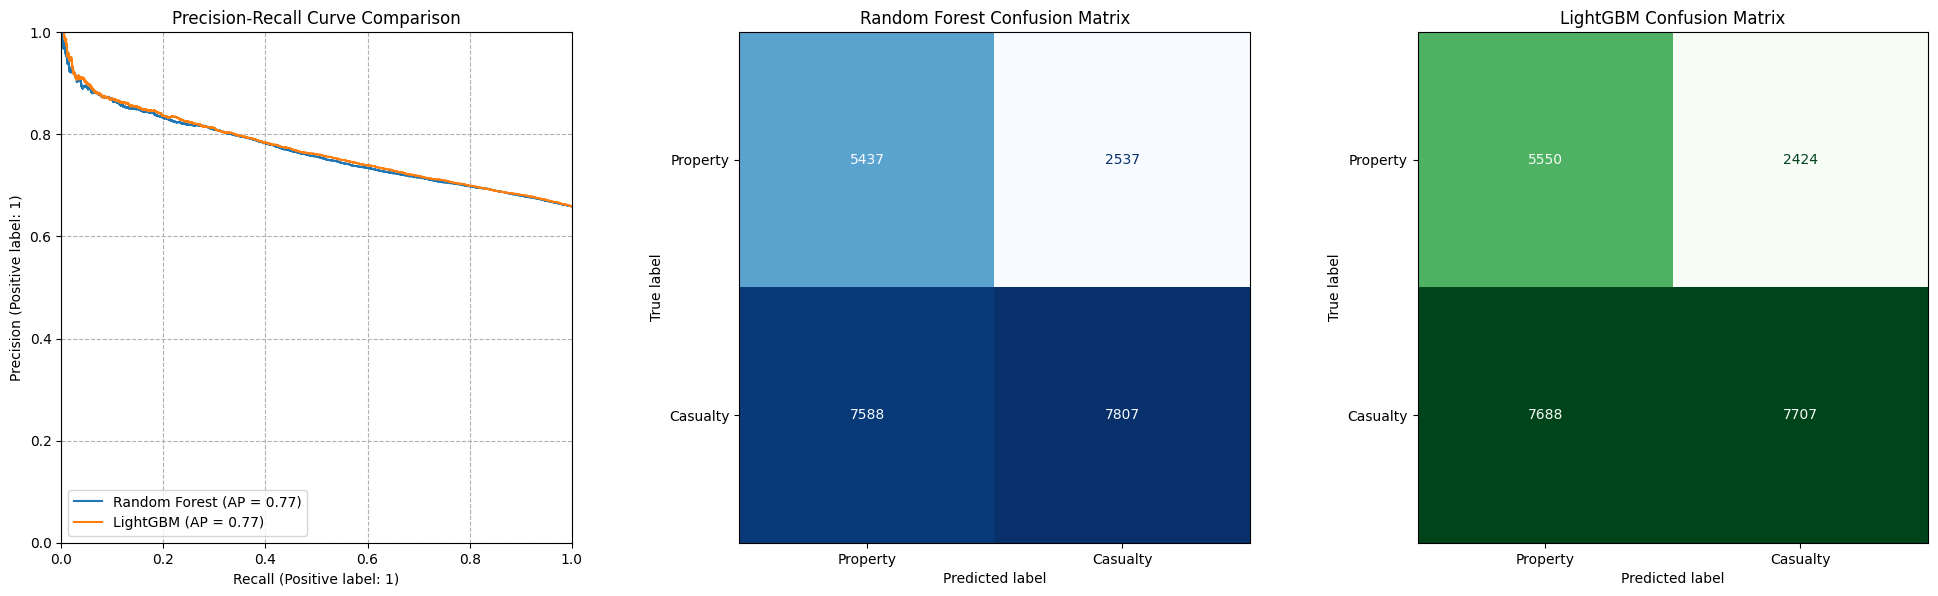

In [ ]:

# We use the 'best' estimators found in the previous step
models = {
    'Random Forest': best_rf,
    'LightGBM': best_lgbm
}

# Metrics we want to measure
scoring = ['precision', 'recall', 'f1', 'average_precision']

results_data = []

for name, model in models.items():
    # Stratified K-Fold is implicit in cross_validate for classifiers, 
    # but we can pass the cv object to be explicit and consistent
    cv_results = cross_validate(model, X_train, y_train_encoded, cv=5, scoring=scoring, n_jobs=-1)
    
    # Calculate Mean and Std for each metric
    row = {'Model': name}
    for metric in scoring:
        mean_score = cv_results[f'test_{metric}'].mean()
        std_score = cv_results[f'test_{metric}'].std()
        row[f'{metric} (Mean ± Std)'] = f"{mean_score:.3f} ± {std_score:.3f}"
    
    results_data.append(row)

# Display Metrics Table
metrics_df = pd.DataFrame(results_data)
print("\n--- Cross-Validation Performance (Training Set) ---")
display(metrics_df)



## PR Curve & Confusion Matrix

In [ ]:

# 1. Fit models on the FULL training set
best_rf.fit(X_train, y_train_encoded)
best_lgbm.fit(X_train, y_train_encoded)

# 2. Setup Plot Layout
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- Plot A: Precision-Recall Curve Comparison ---
# This graph answers: "For a desired Recall, what Precision do I pay?"
for name, model in models.items():
    display_plot = PrecisionRecallDisplay.from_estimator(
        model, 
        X_test, 
        y_test_encoded, 
        name=name, 
        ax=axes[0]
    )
axes[0].set_title("Precision-Recall Curve Comparison")
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1])
axes[0].grid(linestyle='--')

# --- Plot B: Confusion Matrix (Random Forest) ---
ConfusionMatrixDisplay.from_estimator(
    best_rf, 
    X_test, 
    y_test_encoded, 
    display_labels=['Property', 'Casualty'],
    cmap=plt.cm.Blues,
    ax=axes[1],
    colorbar=False
)
axes[1].set_title(f"Random Forest Confusion Matrix")

# --- Plot C: Confusion Matrix (LightGBM) ---
ConfusionMatrixDisplay.from_estimator(
    best_lgbm, 
    X_test, 
    y_test_encoded, 
    display_labels=['Property', 'Casualty'],
    cmap=plt.cm.Greens,
    ax=axes[2],
    colorbar=False
)
axes[2].set_title(f"LightGBM Confusion Matrix")

plt.tight_layout()
plt.show()

### 📊 Intermediate Summary: Selecting the Leading Model
Based on the Cross-Validation results and the PR-Curve comparison, we have reached the following conclusions:

1.  **Stability:** Both models (Random Forest and LightGBM) exhibited very low standard deviation across the validation folds. This indicates that the models are robust, stable, and do not suffer from extreme overfitting to specific data subsets.
2.  **Performance:** The **LightGBM** model showed a slight advantage in the critical **Average Precision** metric (0.772 vs. 0.768). In imbalanced classification tasks, this metric best reflects the model's ability to distinguish between classes across all possible decision thresholds.
3.  **Managing the Trade-off:** Although the Recall at the default threshold (0.5) stands at approximately 50%, the high Average Precision suggests that the model ranks probabilities effectively.
    * **Operational Implication:** We can (and should) lower the decision threshold during the deployment/policy phase to achieve a higher Recall (e.g., 80%), paying a controlled price in Precision, depending on the desired safety policy.

**Decision:** We select **LightGBM** as our final model for analysis, due to its superior performance, computational efficiency, and its compatibility with SHAP for advanced interpretability.

### 🔍 Next Step: From Prediction to Policy (SHAP Analysis)
Now that we have a robust and calibrated model, we proceed to the project's primary objective: **understanding the factors contributing to severe crashes and deriving actionable policy.**

Complex models like LightGBM are often considered "black boxes." To unlock them and derive genuine insights, we will go beyond standard "Feature Importance" and utilize **SHAP Values**.

**What are we looking for?**
Unlike standard importance, which only tells us *which* features matter, SHAP reveals *how* they matter:
* **Directionality:** Does a high value in a feature (e.g., high speed) *increase* or *decrease* the probability of a severe crash?
* **Complexity:** Identifying non-linear relationships captured by the model.

In the following visualizations (specifically the Beeswarm Plot):
* **Red Color:** Indicates a high value of the feature.
* **Right Side (X-axis):** Indicates a positive contribution to the risk (pushing the prediction towards "Casualty").
This analysis will serve as the foundation for the Discussion and Recommendations chapter of our final report.

## feature importent

✅ Great! Transformed data is a DataFrame with column names.


C:\Users\אליאור\AppData\Roaming\Python\Python311\site-packages\shap\explainers\_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


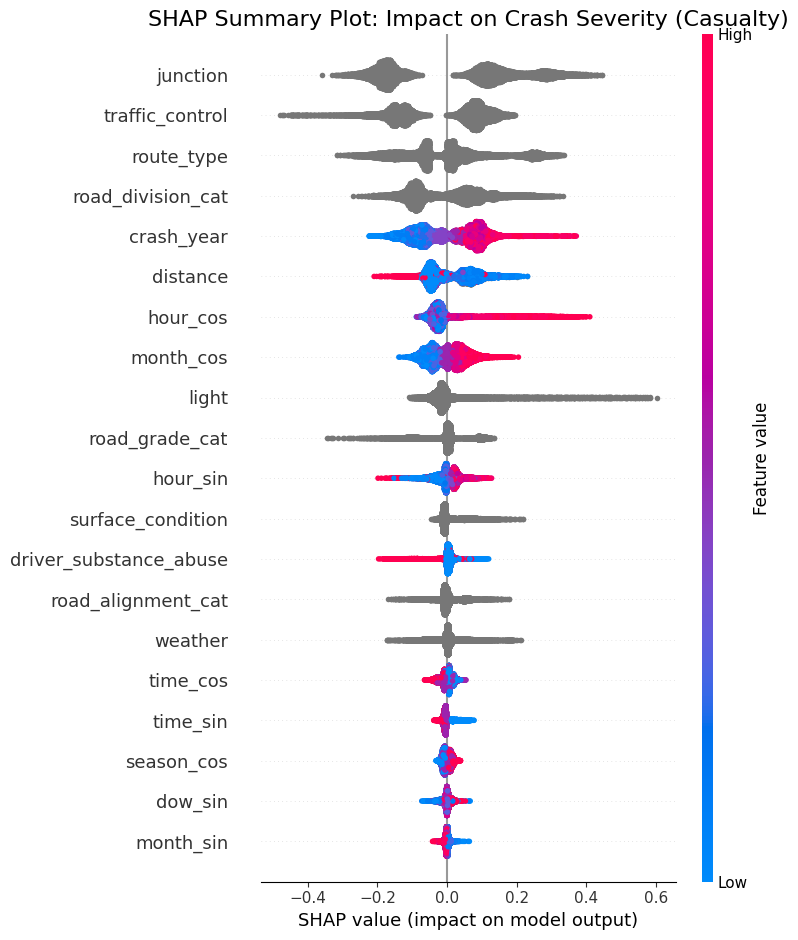

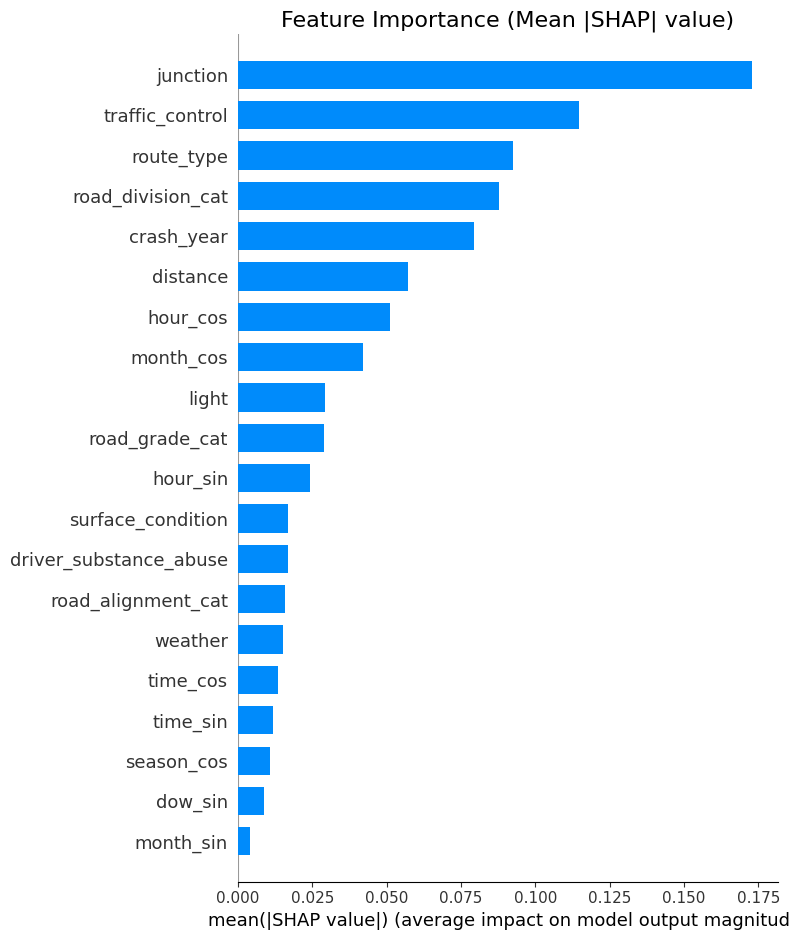

In [57]:
# 1. Prepare the Data
# נשלוף את המודל ואת המעבד מתוך הפייפליין
preprocessor = best_lgbm.named_steps['preprocessor']
model = best_lgbm.named_steps['model']

# בגלל שהגדרת transform_output="pandas", הפקודה הזו תחזיר DataFrame!
# זה מעולה כי השמות של העמודות (feature names) נשמרים בפנים.
X_test_transformed = preprocessor.transform(X_test)

# בדיקה קטנה לראות שהשמות אכן שם (אופציונלי, רק לביטחון)
if isinstance(X_test_transformed, pd.DataFrame):
    print("✅ Great! Transformed data is a DataFrame with column names.")
    feature_names = X_test_transformed.columns
else:
    # גיבוי למקרה שמשהו בהגדרות השתנה
    print("⚠️ Data is numpy array, extracting names manually...")
    feature_names = preprocessor.get_feature_names_out()

# 2. Create SHAP Explainer
# LightGBM הוא מודל עצים, ולכן משתמשים ב-TreeExplainer המהיר
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_transformed)

# טיפול במבנה הפלט של SHAP (בינארי לפעמים מחזיר רשימה של 2 מטריצות)
# אנחנו רוצים את המטריצה של מחלקה 1 (Casualty)
if isinstance(shap_values, list):
    shap_values_class1 = shap_values[1]
else:
    shap_values_class1 = shap_values

# 3. Generate Summary Plot (Beeswarm)
plt.figure(figsize=(12, 10))
shap.summary_plot(
    shap_values_class1, 
    X_test_transformed, 
    # כשמעבירים DataFrame, ה-SHAP לוקח את השמות לבד, אבל נציין אותם ליתר ביטחון
    feature_names=feature_names,
    max_display=20, 
    show=False
)
plt.title("SHAP Summary Plot: Impact on Crash Severity (Casualty)", fontsize=16)
plt.tight_layout()
plt.show()

# 4. Generate Bar Plot (Mean Absolute Importance)
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values_class1, 
    X_test_transformed, 
    feature_names=feature_names, 
    plot_type="bar",
    max_display=20,
    show=False
)
plt.title("Feature Importance (Mean |SHAP| value)", fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:

# ---------------------------------------------------------
# Step 7: Category Risk Analysis (Adapted for Native Categories)
# ---------------------------------------------------------
# Since we use native categorical types, we don't need to decode integers.
# Instead, we map the actual category names to their average SHAP impact.

# 1. Transform X_test using your native_preprocessor
# This gives us a DataFrame where categorical columns are of type 'category' (strings underneath)
preprocessor = best_lgbm.named_steps['preprocessor']
X_test_transformed = preprocessor.transform(X_test)

# List of categorical features you want to inspect (based on your SHAP results)
features_to_analyze = ['junction', 'traffic_control', 'route_type', 'road_grade_cat']

print("--- 🚦 High Risk Category Analysis ---")
print("Positive SHAP = Increases Casualty Risk")
print("Negative SHAP = Reduces Casualty Risk\n")

for feature in features_to_analyze:
    if feature in X_test_transformed.columns:
        # Get the original category values from the transformed data
        # (We convert to string to ensure we can read them)
        categories = X_test_transformed[feature].astype(str)
        
        # Get the corresponding SHAP values for this feature
        # We find the column index to pull the right SHAP column
        col_idx = X_test_transformed.columns.get_loc(feature)
        feature_shap_values = shap_values_class1[:, col_idx]
        
        # Create a temporary DataFrame to group by category
        df_impact = pd.DataFrame({
            'Category': categories,
            'SHAP_Impact': feature_shap_values
        })
        
        # Calculate Mean SHAP impact per category
        risk_ranking = df_impact.groupby('Category')['SHAP_Impact'].mean().sort_values(ascending=False)
        
        # Print the Top 3 Riskiest and Top 3 Safest categories
        print(f"📊 Feature: {feature.upper()}")
        print("  🔴 Top 3 Highest Risk (Increase Severity):")
        for cat, val in risk_ranking.head(3).items():
            print(f"     {cat:<30} (Avg Impact: +{val:.4f})")
            
        print("  🟢 Top 3 Safest (Decrease Severity):")
        for cat, val in risk_ranking.tail(3).items():
            print(f"     {cat:<30} (Avg Impact: {val:.4f})")
        print("-" * 60)

--- 🚦 High Risk Category Analysis ---
Positive SHAP = Increases Casualty Risk
Negative SHAP = Reduces Casualty Risk

📊 Feature: JUNCTION
  🔴 Top 3 Highest Risk (Increase Severity):
     Not Relevant                   (Avg Impact: +0.2880)
     Roundabout                     (Avg Impact: +0.2727)
     Other                          (Avg Impact: +0.2572)
  🟢 Top 3 Safest (Decrease Severity):
     Interchange/Ramp               (Avg Impact: 0.0958)
     Intersection                   (Avg Impact: -0.1767)
     Driveway                       (Avg Impact: -0.2163)
------------------------------------------------------------
📊 Feature: TRAFFIC_CONTROL
  🔴 Top 3 Highest Risk (Increase Severity):
     MISSING                        (Avg Impact: +0.1205)
     No Controls                    (Avg Impact: +0.0785)
     Traffic Signal                 (Avg Impact: +-0.1449)
  🟢 Top 3 Safest (Decrease Severity):
     Traffic Signal                 (Avg Impact: -0.1449)
     Person                    

להוסיף מסקנות  
להסתכל על המקדמים של הרגרסיה הלוגיסית